### Tasks:
1. **Data Import and Cleaning**:

    - Import the dataset using Pandas.
    - Identify missing values and handle them appropriately.
    - Use NumPy to convert relevant columns to numerical types if necessary.

2. **Exploratory Data Analysis**:

    - Utilize Pandas to summarize key statistics (mean, median, standard deviation) for numerical columns.
    - Explore the distribution of power plants by country and fuel type.

3. **Statistical Analysis**:

    - Perform a statistical analysis of power output by fuel type using NumPy’s statistical functions.
    - Use hypothesis testing to determine if the mean power output differs significantly between different fuel types.

4. **Time Series Analysis**:

    - If the dataset includes time-related data (like year of establishment), use NumPy to analyze trends over time.
    - Explore how the mix of fuel types for power generation has evolved over the years.

5. **Advanced Visualization**:

    - Create visualizations using Matplotlib and Seaborn to illustrate your findings.
    - Consider plotting the geographical distribution of power plants using latitude and longitude data, if available.

6. **Matrix Operations in Real-World Context**:

     - Demonstrate matrix operations by analyzing relationships between different attributes (e.g., fuel type, capacity, and geographic location).
    - Discuss the relevance of eigenvectors and eigenvalues in this context.

7. **Integrating NumPy with Pandas and Matplotlib**:

    - Show how NumPy can be used to enhance data manipulation in Pandas and data visualization in Matplotlib.
    - Provide examples, such as using NumPy arrays for complex filtering in Pandas or for creating sophisticated plots in Matplotlib.


### Solution

In [169]:
# import basic modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [170]:
# Basic workflow
df = pd.read_csv('data/global_power_plant_database.csv')

df.head(5)

/var/folders/8g/b0fs32r14l57mfjp3l9lh_nw0000gn/T/ipykernel_66717/2925826720.py:2: DtypeWarning: Columns (0: other_fuel3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/global_power_plant_database.csv')


,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,...,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017,estimated_generation_note_2013,estimated_generation_note_2014,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017
0,AFG,Afghanistan,Kajaki Hydroelectric Power Plant Afghanistan,GEODB0040538,33.0,32.322,65.1190,Hydro,NaN,NaN,...,123.77,162.90,97.39,137.76,119.50,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
1,AFG,Afghanistan,Kandahar DOG,WKS0070144,10.0,31.670,65.7950,Solar,NaN,NaN,...,18.43,17.48,18.25,17.70,18.29,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
2,AFG,Afghanistan,Kandahar JOL,WKS0071196,10.0,31.623,65.7920,Solar,NaN,NaN,...,18.64,17.58,19.10,17.62,18.72,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
3,AFG,Afghanistan,Mahipar Hydroelectric Power Plant Afghanistan,GEODB0040541,66.0,34.556,69.4787,Hydro,NaN,NaN,...,225.06,203.55,146.90,230.18,174.91,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
4,AFG,Afghanistan,Naghlu Dam Hydroelectric Power Plant Afghanistan,GEODB0040534,100.0,34.641,69.7170,Hydro,NaN,NaN,...,406.16,357.22,270.99,395.38,350.80,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1


In [171]:
df.shape

(34936, 36)

In [172]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34936 entries, 0 to 34935
Data columns (total 36 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   country                         34936 non-null  str    
 1   country_long                    34936 non-null  str    
 2   name                            34936 non-null  str    
 3   gppd_idnr                       34936 non-null  str    
 4   capacity_mw                     34936 non-null  float64
 5   latitude                        34936 non-null  float64
 6   longitude                       34936 non-null  float64
 7   primary_fuel                    34936 non-null  str    
 8   other_fuel1                     1944 non-null   str    
 9   other_fuel2                     276 non-null    str    
 10  other_fuel3                     92 non-null     str    
 11  commissioning_year              17447 non-null  float64
 12  owner                           20868 non-n

In [173]:
df.describe()

,capacity_mw,latitude,longitude,commissioning_year,year_of_capacity_data,generation_gwh_2013,generation_gwh_2014,generation_gwh_2015,generation_gwh_2016,generation_gwh_2017,generation_gwh_2018,generation_gwh_2019,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017
count,34936.000000,34936.000000,34936.000000,17447.000000,14887.000000,6417.000000,7226.000000,8203.000000,9144.000000,9500.000000,9637.000000,9659.000000,16120.000000,16503.000000,17050.000000,17570.000000,33138.000000
mean,163.355148,32.816637,-6.972803,1997.414823,2018.218849,592.696107,656.863891,762.368840,693.149763,661.834161,517.320785,423.922436,239.112221,242.431122,235.866067,235.695265,716.443378
std,489.636072,22.638603,78.405850,23.397835,1.606428,2174.833482,2231.464288,2533.459828,2404.516759,2369.296957,1975.302686,1698.506485,1191.258172,1285.798297,1267.005223,1259.559841,2484.361200
min,1.000000,-77.847000,-179.977700,1896.000000,2000.000000,-947.600000,-989.619000,-864.428000,-768.620000,-934.944000,-982.622000,-780.339000,1.120000,0.870000,0.440000,0.300000,0.000000
25%,4.900000,29.256475,-77.641550,1988.000000,2017.000000,1.947000,2.260000,2.664500,2.729000,2.467000,2.242000,2.751500,8.620000,8.680000,8.380000,8.322500,8.180000
50%,16.745000,39.727750,-2.127100,2007.000000,2019.000000,23.426000,23.608500,26.142000,22.462389,17.876500,12.530000,11.530000,27.620000,28.250000,26.830000,27.555000,37.590000
75%,75.344250,46.263125,49.502675,2014.000000,2019.000000,199.706000,226.322250,285.862583,249.866750,214.505150,151.117000,122.781498,106.805000,106.980000,103.120000,107.237500,229.565000
max,22500.000000,71.292000,179.388700,2020.000000,2019.000000,50834.000000,32320.917000,37433.607000,32377.477000,36448.643000,35136.000000,31920.368000,48675.060000,58470.770000,57113.350000,60859.730000,82810.770000


In [174]:
# Check how many nulls in each column
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)

pd.DataFrame({"missing": missing, "missing_%": missing_pct}).head(15)

,missing,missing_%
other_fuel3,34844,99.736661
other_fuel2,34660,99.209984
other_fuel1,32992,94.435539
generation_gwh_2013,28519,81.632127
generation_gwh_2014,27710,79.316464
generation_gwh_2015,26733,76.519922
generation_gwh_2016,25792,73.826425
generation_gwh_2017,25436,72.807419
generation_gwh_2018,25299,72.415274
generation_gwh_2019,25277,72.352301


In [175]:
# Drop columns with more the 50% of the data missing

threshold = 0.50  # 50%
# Create pandas Series with percentages of missing data for each column
missing_pct = df.isna().mean()
# Create list of columns that are above the threshold of 50%
cols_drop = missing_pct[missing_pct > threshold].index.tolist()

print(f"Shape before drop: {df.shape}")
print("Dropping", len(cols_drop), "columns:")
print(cols_drop)

df = df.drop(columns=cols_drop)
print(f"Shape after drop: {df.shape}")

Shape before drop: (34936, 36)
Dropping 17 columns:
['other_fuel1', 'other_fuel2', 'other_fuel3', 'commissioning_year', 'wepp_id', 'year_of_capacity_data', 'generation_gwh_2013', 'generation_gwh_2014', 'generation_gwh_2015', 'generation_gwh_2016', 'generation_gwh_2017', 'generation_gwh_2018', 'generation_gwh_2019', 'generation_data_source', 'estimated_generation_gwh_2013', 'estimated_generation_gwh_2014', 'estimated_generation_gwh_2015']
Shape after drop: (34936, 19)


In [176]:
# Handle the remaining missing columns
# Create pandas Series with remaining missing values
missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing

estimated_generation_gwh_2016    17366
owner                            14068
estimated_generation_gwh_2017     1798
geolocation_source                 419
url                                 18
source                              15
dtype: int64

In [177]:
# Fill text columns with "Unknown"
# Create list of all column names with str values
text_cols = df.select_dtypes(include="str").columns
# Substitute every null in each text column with "Unknown"
for c in text_cols:
    df[c] = df[c].fillna("Unknown")

In [178]:
# Median impute numeric columns ONLY if missing is small
# Create list of all column names with numeric values
num_cols = df.select_dtypes(include=[np.number]).columns
# Substitute every null with columns with <= 10% missing with median 
for c in num_cols:
    miss = df[c].isna().mean()
    if miss > 0 and miss <= 0.10:
        df[c] = df[c].fillna(df[c].median())

In [179]:
# Keep numeric columns with > 10%
# Create a binary column for each numeric column with > 10% missing
for c in num_cols:
    miss = df[c].isna().mean()
    if miss > 0.10:
        df[c + "_missing"] = df[c].isna().astype(int)

In [180]:
# Check which columns remain with nulls
df.columns[df.isna().any()].to_list()

['estimated_generation_gwh_2016']

**Observation**: The column estimated_generation_gwh_2016 contains approximately 50% missing values. To avoid introducing statistical bias through large-scale imputation, these missing values were preserved, and analyses involving this variable were performed using complete cases only.

In [181]:
df.describe(include=[np.number])

,capacity_mw,latitude,longitude,estimated_generation_gwh_2016,estimated_generation_gwh_2017,estimated_generation_gwh_2016_missing
count,34936.000000,34936.000000,34936.000000,17570.000000,34936.000000,34936.000000
mean,163.355148,32.816637,-6.972803,235.695265,681.505825,0.497080
std,489.636072,22.638603,78.405850,1259.559841,2424.229996,0.499999
min,1.000000,-77.847000,-179.977700,0.300000,0.000000,0.000000
25%,4.900000,29.256475,-77.641550,8.322500,8.960000,0.000000
50%,16.745000,39.727750,-2.127100,27.555000,37.590000,0.000000
75%,75.344250,46.263125,49.502675,107.237500,195.640000,1.000000
max,22500.000000,71.292000,179.388700,60859.730000,82810.770000,1.000000


In [182]:
print(df.columns)

Index(['country', 'country_long', 'name', 'gppd_idnr', 'capacity_mw',
       'latitude', 'longitude', 'primary_fuel', 'owner', 'source', 'url',
       'geolocation_source', 'estimated_generation_gwh_2016',
       'estimated_generation_gwh_2017', 'estimated_generation_note_2013',
       'estimated_generation_note_2014', 'estimated_generation_note_2015',
       'estimated_generation_note_2016', 'estimated_generation_note_2017',
       'estimated_generation_gwh_2016_missing'],
      dtype='str')


In [183]:
# Check distribution of power plants by country
power_plants_by_country = df['country_long'].value_counts().reset_index().rename(columns={'country_long': 'country', 'count': 'power_plants'})
print("Countries with the largest number of power plants:")
print()
print(power_plants_by_country.head(10))

print()
print("Countries with the smallest number of power plants:")
print()
print(power_plants_by_country.tail(10))

Countries with the largest number of power plants:

                    country  power_plants
0  United States of America          9833
1                     China          4235
2            United Kingdom          2751
3                    Brazil          2360
4                    France          2155
5                     India          1589
6                   Germany          1309
7                    Canada          1159
8                     Spain           829
9                    Russia           545

Countries with the smallest number of power plants:

            country  power_plants
157         Liberia             2
158      Luxembourg             2
159        Zimbabwe             2
160        Djibouti             1
161   Guinea-Bissau             1
162         Lesotho             1
163       Palestine             1
164     Saint Lucia             1
165        Suriname             1
166  Western Sahara             1


In [184]:
# Check distribution of power plants by fuel type
power_plants_by_fuel_type = df['primary_fuel'].value_counts().reset_index().rename(columns={'count': 'power_plants'})
print("Distribution of power plants by fuel type:")
print()
print(power_plants_by_fuel_type)


Distribution of power plants by fuel type:

      primary_fuel  power_plants
0            Solar         10665
1            Hydro          7156
2             Wind          5344
3              Gas          3998
4             Coal          2330
5              Oil          2320
6          Biomass          1430
7            Waste          1068
8          Nuclear           195
9       Geothermal           189
10         Storage           135
11           Other            43
12    Cogeneration            41
13         Petcoke            12
14  Wave and Tidal            10


In [185]:
fuel_groups = df.groupby('primary_fuel')['capacity_mw']

results = {}

for fuel, group in fuel_groups:
    arr = group.to_numpy()
    results[fuel] = {
        "count": len(arr),
        "mean": np.mean(arr),
        "median": np.median(arr),
        "std": np.std(arr, ddof=1),
        "variance": np.var(arr, ddof=1)
    }

stats_df = pd.DataFrame(results).T.sort_values("mean", ascending=False)
stats_df



,count,mean,median,std,variance
Nuclear,195.0,2091.855179,1888.00000,1303.509273,1.699136e+06
Coal,2330.0,843.579828,600.00000,888.187187,7.888765e+05
Gas,3998.0,373.449375,147.50000,560.934146,3.146471e+05
Petcoke,12.0,202.048125,65.48875,476.986459,2.275161e+05
Hydro,7156.0,147.171551,20.00000,549.809328,3.022903e+05
Oil,2320.0,112.878754,9.00000,392.009039,1.536711e+05
Cogeneration,41.0,98.731707,31.90000,283.428252,8.033157e+04
Other,43.0,84.020000,40.00000,145.891392,2.128430e+04
Geothermal,189.0,67.130952,30.00000,114.640890,1.314253e+04
Wave and Tidal,10.0,55.220000,5.00000,101.440708,1.029022e+04


In [186]:
# Compare mean capacity for the Coal and Solar
coal = df[df["primary_fuel"]=="Coal"]["capacity_mw"].to_numpy()
solar = df[df["primary_fuel"]=="Solar"]["capacity_mw"].to_numpy()

observed_diff = coal.mean() - solar.mean()
print("Coal vs Solar energy")
print(f"Observed difference in mean output: {observed_diff.round(1)} MW")

Coal vs Solar energy
Observed difference in mean output: 825.9 MW


In [187]:
# Bootstrap
rng = np.random.default_rng(0)
B = 5000
boot_diffs = np.empty(B)

for i in range(B):
    c_sample = rng.choice(coal, size=len(coal), replace=True)
    s_sample = rng.choice(solar, size=len(solar), replace=True)
    boot_diffs[i] = c_sample.mean() - s_sample.mean()

ci = np.percentile(boot_diffs, [2.5, 97.5])
print(ci.round(1))

[789.4 862.2]


**Observation**: The mean installed capacity of coal power plants is significantly higher than that of solar power plants. The 95% bootstrap confidence interval for the difference in means is [789.4, 862.2] MW, which does not include zero, indicating strong statistical evidence against the null hypothesis of equal means.

In [188]:
# Restore the original dataset
df_original = pd.read_csv("data/global_power_plant_database.csv")

# Merge the date datapoints
df = df.merge(
    df_original[["gppd_idnr", "commissioning_year"]],
    on="gppd_idnr",
    how="left"
)

/var/folders/8g/b0fs32r14l57mfjp3l9lh_nw0000gn/T/ipykernel_66717/3611620740.py:2: DtypeWarning: Columns (0: other_fuel3) have mixed types. Specify dtype option on import or set low_memory=False.
  df_original = pd.read_csv("data/global_power_plant_database.csv")


In [189]:
# Create separate dataframe without missing rows on comissioning_year
time_df = df.dropna(subset=["commissioning_year"])

**Observation**: Since plants without known year cannot contribute to time trends, we created a separate dataframe to analize those trends (thus not affecting our cleaned-up df).

In [190]:
# Create NumPy array of years of power plant creation
years = time_df["commissioning_year"].astype(int).to_numpy()

unique_years = np.unique(years)


counts = np.array([
    np.sum(years == year)
    for year in unique_years
])

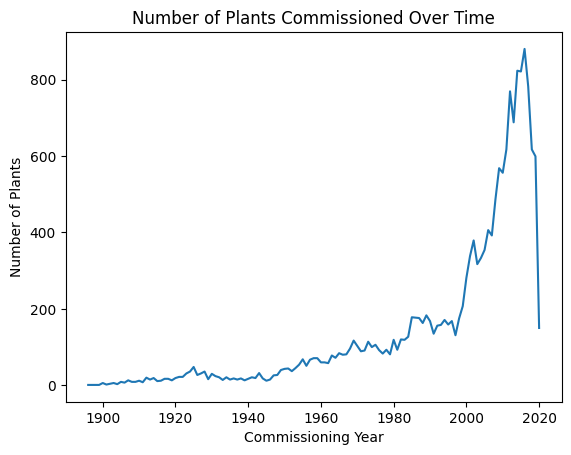

In [191]:
# Plot the time series
plt.plot(unique_years, counts)
plt.xlabel("Commissioning Year")
plt.ylabel("Number of Plants")
plt.title("Number of Plants Commissioned Over Time")
plt.show()

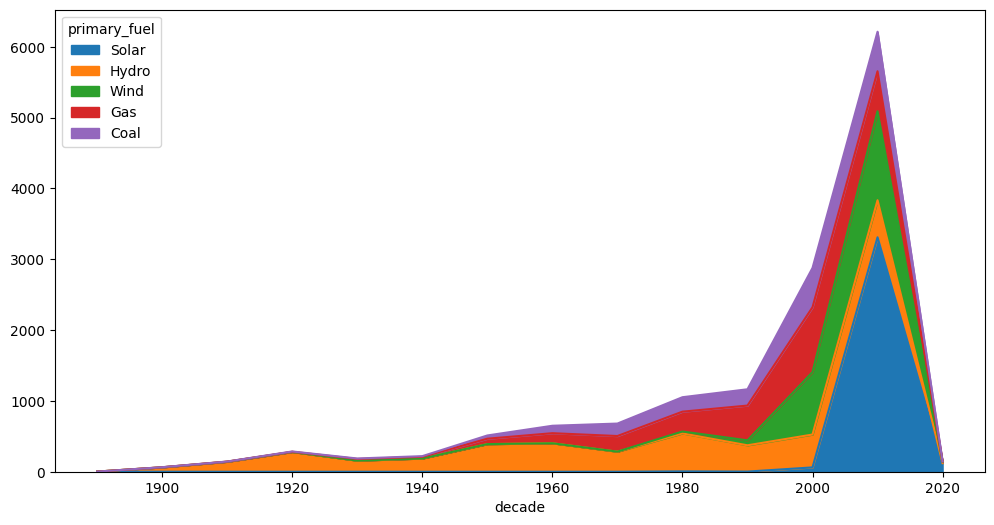

In [192]:
# Create a 'decade' column (e.g. 1990, 2000)
time_df["decade"] = (time_df["commissioning_year"] // 10) * 10

# Group by decade + primary fuel
fuel_decade = (
    time_df
    .groupby(["decade", "primary_fuel"])
    .size()
    .reset_index(name="count")
)

# Pivot (from long form to wide form)
pivot_decade = fuel_decade.pivot(
    index="decade",
    columns="primary_fuel",
    values="count"
).fillna(0)

top_fuels = df["primary_fuel"].value_counts().head(5).index

pivot_top = pivot_decade[top_fuels]

# Plot the data
pivot_top.plot(kind="area", stacked=True, figsize=(12,6))
plt.show()

**Observation**: he temporal analysis reveals a clear structural shift in global energy infrastructure. Early decades were dominated by hydroelectric and coal-based power generation. Beginning in the mid-20th century, gas-fired plants increased significantly. From the 2000s onward, solar and wind installations expanded rapidly, indicating a strong transition toward renewable energy technologies. The apparent spike in recent decades reflects both genuine growth and improved reporting coverage in the dataset.

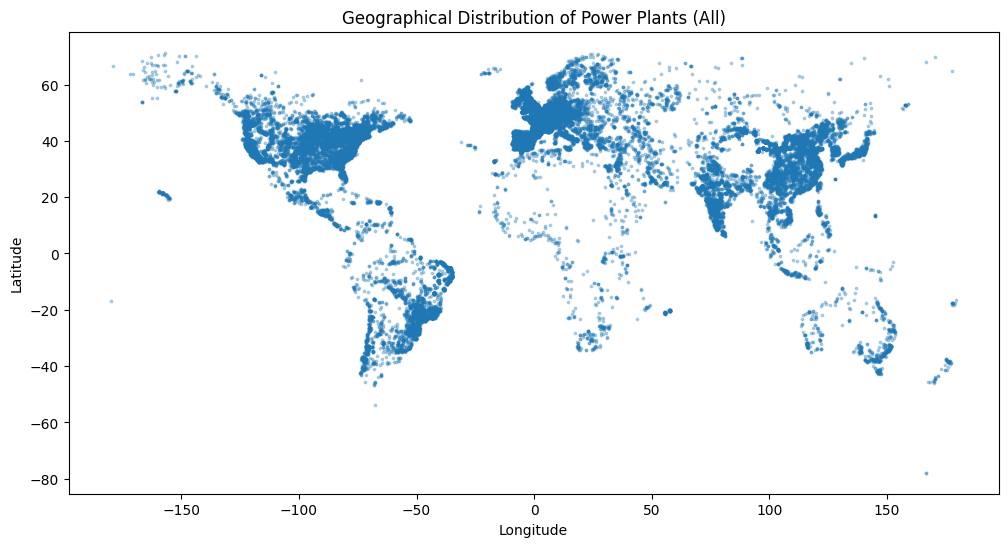

In [193]:
plt.figure(figsize=(12,6))
plt.scatter(df["longitude"], df["latitude"], s=3, alpha=0.3)
plt.title("Geographical Distribution of Power Plants (All)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

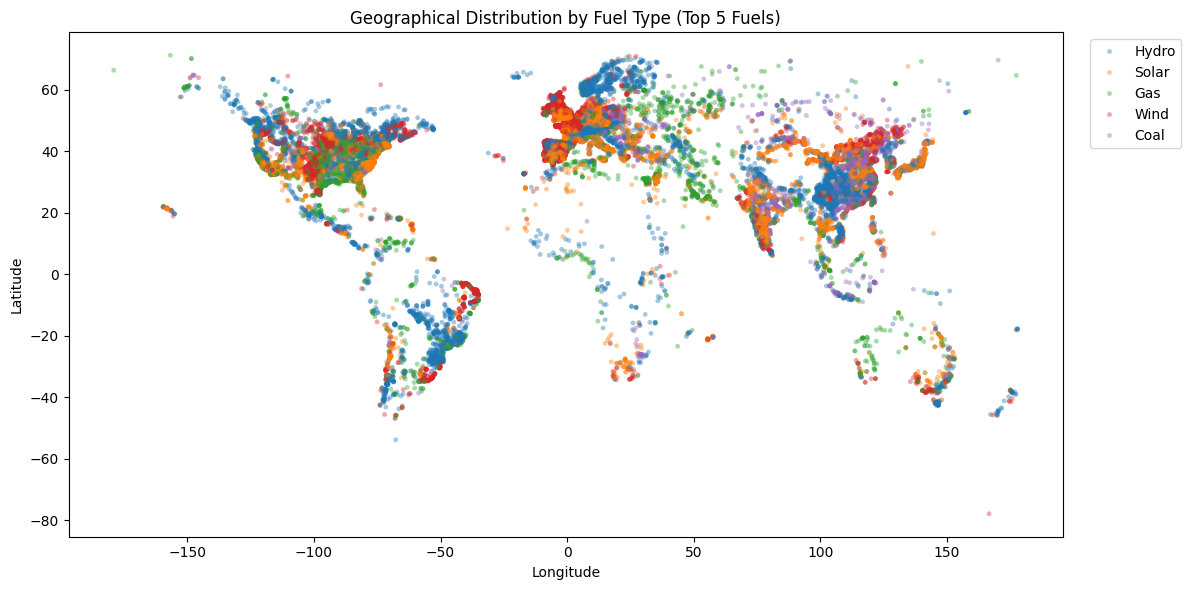

In [194]:
geo = df[df["primary_fuel"].isin(top_fuels)].copy()

plt.figure(figsize=(12,6))
sns.scatterplot(
    data=geo,
    x="longitude", y="latitude",
    hue="primary_fuel",
    s=12, alpha=0.4, linewidth=0
)
plt.title("Geographical Distribution by Fuel Type (Top 5 Fuels)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

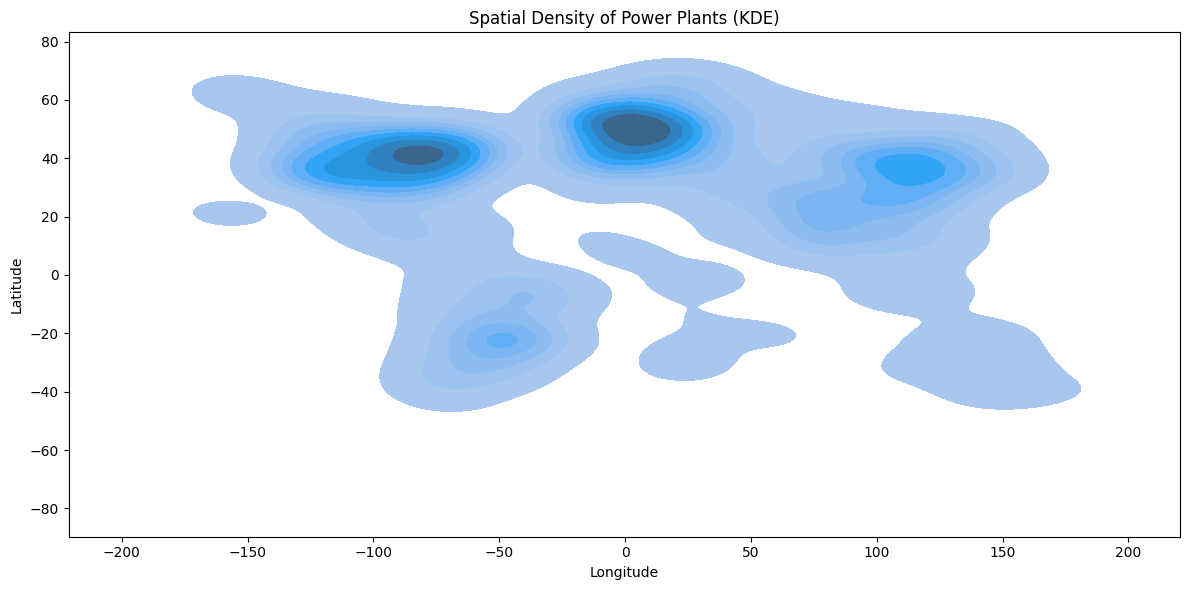

In [195]:
plt.figure(figsize=(12,6))
sns.kdeplot(
    data=df,
    x="longitude", y="latitude",
    fill=True,
    thresh=0.02
)
plt.title("Spatial Density of Power Plants (KDE)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

**Observation**: The global scatter plot shows that power plants are concentrated in populated and industrial regions (e.g., North America, Europe, South and East Asia). Coloring by fuel type suggests different geographic patterns: hydro plants tend to align with mountainous/water-rich regions, while solar and wind appear more dispersed and often cluster in regions with strong renewable deployment. A density plot highlights the major global hotspots of plant locations.

In [196]:
# Create a ndarray with numeric columns from the dataframe
num_cols = [
    "capacity_mw",
    "latitude",
    "longitude",
    "estimated_generation_gwh_2017"
]

X = df[num_cols].to_numpy()
X.shape

(34936, 4)

In [197]:
# Calculate correlation matrix
corr_matrix = np.corrcoef(X, rowvar=False)

# Turn into dataframe
corr_df = pd.DataFrame(
    corr_matrix,
    index=num_cols,
    columns=num_cols
)

corr_df

,capacity_mw,latitude,longitude,estimated_generation_gwh_2017
capacity_mw,1.000000,-0.013218,0.151525,0.946248
latitude,-0.013218,1.000000,-0.068354,-0.013642
longitude,0.151525,-0.068354,1.000000,0.144950
estimated_generation_gwh_2017,0.946248,-0.013642,0.144950,1.000000


**Observation**: The correlation matrix reveals a very strong positive relationship (r ≈ 0.95) between installed capacity and estimated annual generation, indicating that larger power plants produce proportionally more electricity. Geographic coordinates (latitude and longitude) show negligible correlation with capacity and generation, suggesting that plant size is not strongly determined by geographic location at the global scale. These results confirm expected structural relationships within the dataset.

**Observation**: Eigenvectors and Eigenvalues were not covered here, becuase these topics were not studied in class.

In [198]:
# Extract NumPy arrays
capacity = df["capacity_mw"].to_numpy()
latitude = df["latitude"].to_numpy()
generation = df["estimated_generation_gwh_2017"].to_numpy()

# Create complex boolean mask using NumPy
mask = (
    (capacity > np.median(capacity)) &
    (latitude > 0) &
    (generation > np.percentile(generation, 75))
)

# Apply mask back to Pandas
filtered_df = df[mask]
filtered_df.head()

,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,owner,source,...,geolocation_source,estimated_generation_gwh_2016,estimated_generation_gwh_2017,estimated_generation_note_2013,estimated_generation_note_2014,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017,estimated_generation_gwh_2016_missing,commissioning_year
4,AFG,Afghanistan,Naghlu Dam Hydroelectric Power Plant Afghanistan,GEODB0040534,100.0,34.6410,69.7170,Hydro,Unknown,GEODB,...,GEODB,395.38,350.80,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,0,NaN
10,ALB,Albania,Fierza,WRI1002170,500.0,42.2514,20.0431,Hydro,Unknown,Energy Charter Secretariat,...,GEODB,1795.15,1648.24,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,0,1978.0
11,ALB,Albania,Koman,WRI1002171,600.0,42.1033,19.8224,Hydro,Unknown,Energy Charter Secretariat,...,GEODB,2434.84,1982.72,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,0,1985.0
15,ALB,Albania,Vau i Dijes,WRI1002175,250.0,42.0137,19.6359,Hydro,Unknown,Energy Charter Secretariat,...,GEODB,897.47,703.64,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,0,1971.0
19,DZA,Algeria,Ain Djasser,WRI1023776,520.0,35.8665,6.0262,Gas,SociÃ©te AlgÃ©rienne de Production de l\'Elect...,Arab Union of Electricity,...,KTH,NaN,2171.28,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,NO-ESTIMATION,CAPACITY-FACTOR-V1,1,NaN


**Observation**: NumPy was used to construct vectorized boolean masks based on percentile thresholds and geographic constraints. This demonstrates how NumPy’s statistical functions and logical operations can enhance complex filtering within Pandas.

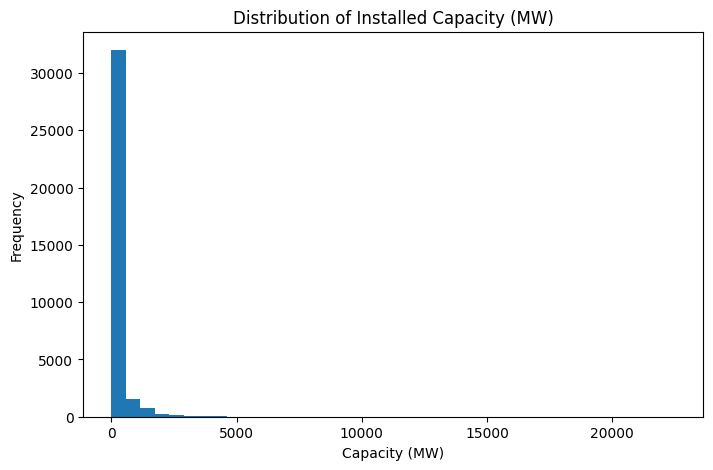

In [199]:
# Compute bins using NumPy
capacity = df["capacity_mw"].to_numpy()

bins = np.linspace(
    capacity.min(),
    capacity.max(),
    40
)

#  Plot with Matplotlib
plt.figure(figsize=(8,5))
plt.hist(capacity, bins=bins)
plt.title("Distribution of Installed Capacity (MW)")
plt.xlabel("Capacity (MW)")
plt.ylabel("Frequency")
plt.show()

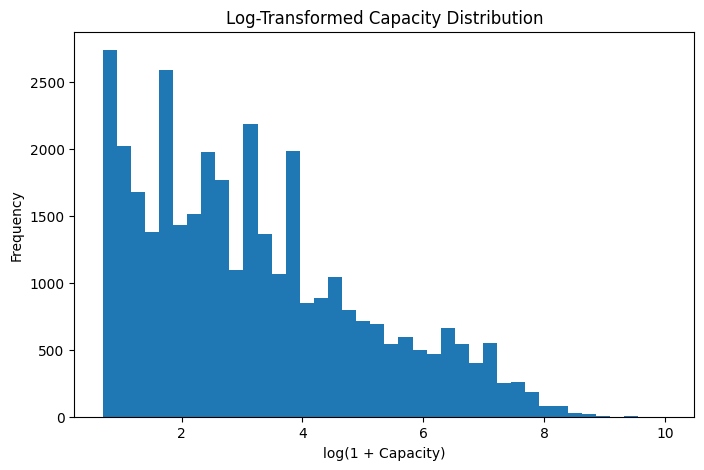

In [200]:
# Log-transform using NumPy (because capacity is highly skewed)
log_capacity = np.log1p(capacity)

# Plot Log-transformed capacity
plt.figure(figsize=(8,5))
plt.hist(log_capacity, bins=40)
plt.title("Log-Transformed Capacity Distribution")
plt.xlabel("log(1 + Capacity)")
plt.ylabel("Frequency")
plt.show()

**Observation**: NumPy transformations such as logarithmic scaling and standardization improve the interpretability of visualizations by addressing skewness in the capacity distribution. These examples illustrate the complementary role of NumPy in both analytical computation and graphical representation.